In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
import tasep_models as tm
from tasep_models import *
from Bio import pairwise2
from Bio.pairwise2 import format_alignment  
import multiprocessing as mp
import os
mp.set_start_method('spawn', force=True)
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning:multiprocessing.resource_tracker'

In [2]:
# reload module microlive
import importlib
importlib.reload(mi)

In [3]:
current_dir = Path().resolve()
print(f"Current directory: {current_dir}")

Current directory: /Users/nzlab-la/Desktop/cotranslational_folding/modeling/TASEP


In [4]:
# Load the sequences.
HA_TAG = 'YPYDVPDYA'
GFP_TAG = 'LEFVTAA'  
MCHERRY_TAG = 'QYERAEG'
XBP1 = 'KDPVPYQPPFLCQWGRHQPAWKPLMN'
TAG_list = [HA_TAG, GFP_TAG, MCHERRY_TAG]

In [5]:
GFPuv = 'SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYAVQCFSRYPDHMKRHDFFKSAMPEGYVQERTISFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYITADKQKNGIKANFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
mCherry ='GVSKGEEDNMAIIKEFMRFKVHMEGSVNGHEFEIEGEGEGRPYEGTQTAKLKVTKGGPLPFAWDILSPQFMYASKAYVKHPADIPDYLKLSFPEGFKWERVMNFEDGGVVTVTQDSSLQDGEFIYKVKLRGTNFPSDGPVMQKKTMGWEASSERMYPEDGALKGEIKQRLKLKDGGHYDAEVKTTYKAKKPVQLPGAYNVNIKLDITSHNEDYTIVEQYERAEGRHSTGGMDELYKG'

In [6]:
# Load sequences.

gene_sequence_4xmGFPuvq_2xmCherryq = current_dir.parents[1].joinpath('data', 'gene_sequences', 'pRS032 (pUB-RBsmHA-4xmGFPuvq-2xmCherryq-24xMS2).dna') # slow folding
gene_sequence_4xsfGFPq_2xmCherryq = current_dir.parents[1].joinpath('data', 'gene_sequences', 'pRS027 (pUB-RBsmHA-4xsfGFPq-2xmCherryq-24xMS2).dna') # fast folding

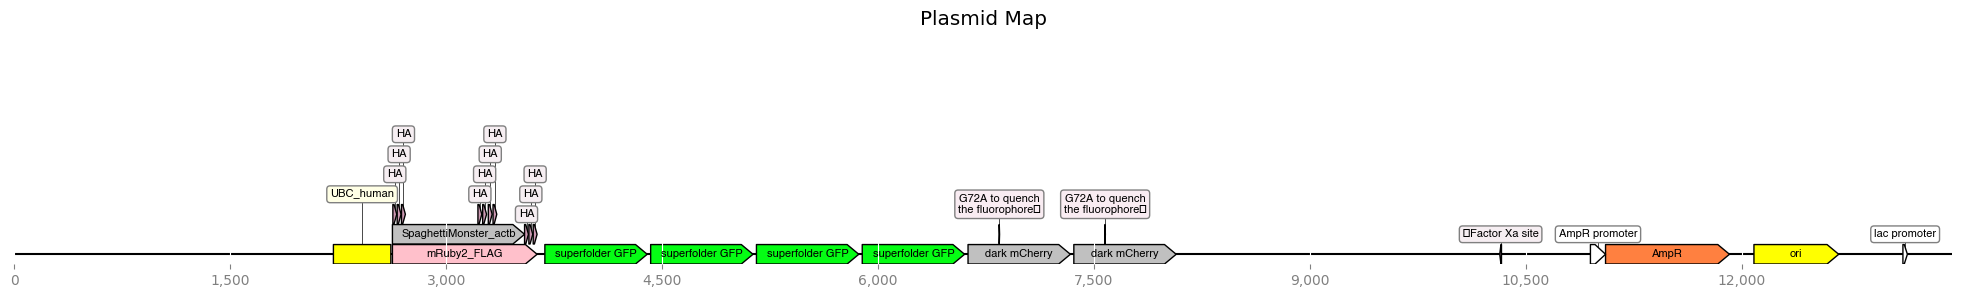

Plasmid name: pRS027 (pUB-RBsmHA-4xsfGFPq-2xmCherryq-24xMS2)


In [7]:
def read_gene_sequence(file_path, TAG_list):
    protein, rna, _, indexes_tags, _, seq_record, graphic_features = read_sequence(
        seq=file_path, TAG=TAG_list, min_protein_length=50
    )
    plasmid_figure = plot_plasmid(seq_record, graphic_features, figure_width=25, figure_height=3)
    gene_length = len(protein) + 1  # adding 1 to account for the stop codon
    probe_data = {}
    for i, (tag, tag_positions) in enumerate(zip(TAG_list, indexes_tags)):
        probe_vector = create_probe_vector(tag_positions, gene_length)
        probe_data[f'tag_{i}'] = {
            'tag_sequence': tag,
            'positions': tag_positions,
            'position_cumulative_vector': probe_vector
        }
    return {
        "protein": protein,
        "rna": rna,
        "gene_length": gene_length,
        "probe_data": probe_data,  # Dictionary with all probe information
        "plasmid_figure": plasmid_figure,
        "seq_record": seq_record,
        "graphic_features": graphic_features,
        "num_probes": len(indexes_tags)
    }

selected_gene_sequence = gene_sequence_4xsfGFPq_2xmCherryq #gene_sequence_4xsfGFPq_2xmCherryq
data_sequence = read_gene_sequence(selected_gene_sequence, TAG_list)

plasmid_name = selected_gene_sequence.stem
print(f"Plasmid name: {plasmid_name}")


In [8]:
# # Initial conditions
# ki = 0.02  # Initiation rate
# global_elongation_rate = 5  # Elongation rates for positions 1 to N-1

ki = 0.06  # Initiation rate
global_elongation_rate = 5  # Elongation rates for positions 1 to N-1

number_repetitions = 200
burnin_time = 2500
t_max = 360*10 #timePerturbationApplication + 25*60  # Maximum time
step_size_in_sec = 5 # 5
time_array = np.arange(0, t_max, step_size_in_sec)
number_tested_parameters = 5
MAD_THRESHOLD_FACTOR = 4
folding_delay = 10  # seconds
efficiency_list = [1, 1]  # binding efficiency for the two probes
ke = calculate_codon_elongation_rates (data_sequence['rna'], global_elongation_rate=global_elongation_rate)

intensity_vector_first_signal_ode,intensity_vector_second_signal_ode = simulate_TASEP_ODE(ki, ke, 
                                                                                          gene_length = data_sequence['gene_length'], 
                                                                                          t_max = t_max,
                                                                                          first_probe_position_vector = data_sequence['probe_data']['tag_0']['position_cumulative_vector'],
                                                                                          second_probe_position_vector = data_sequence['probe_data']['tag_1']['position_cumulative_vector'],
                                                                                          burnin_time = burnin_time,
                                                                                          time_interval_in_seconds = step_size_in_sec)

constant_elongation_rate = None # this is a signal to the SSA to use the elongation rates considering sequence variability.
list_ribosome_trajectories,list_occupancy_output, matrix_intensity_first_signal_RT, matrix_intensity_second_signal_RT = simulate_TASEP_SSA(ki, ke, 
                                                                                                                        gene_length = data_sequence['gene_length'],
                                                                                                                        t_max = t_max,
                                                                                                                        time_interval_in_seconds = step_size_in_sec,
                                                                                                                        number_repetitions = number_repetitions, 
                                                                                                                        first_probe_position_vector = data_sequence['probe_data']['tag_0']['position_cumulative_vector'],
                                                                                                                        second_probe_position_vector = data_sequence['probe_data']['tag_1']['position_cumulative_vector'],
                                                                                                                        burnin_time = burnin_time,
                                                                                                                        folding_delay=folding_delay,
                                                                                                                        constant_elongation_rate = constant_elongation_rate,
                                                                                                                        efficiency_list = efficiency_list,
                                                                                                                        fast_output = False)


In [21]:
data_sequence['gene_length']

1826

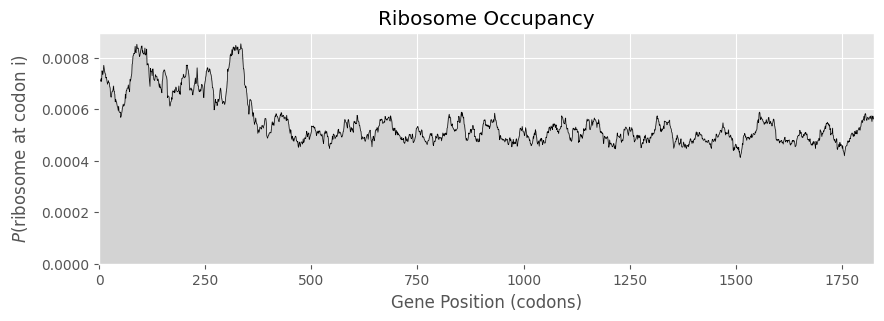

In [9]:
plot_ribosome_density(list_occupancy_output, data_sequence, selected_trajectory = 0, figsize=(10,3), smooth_window = 40,)

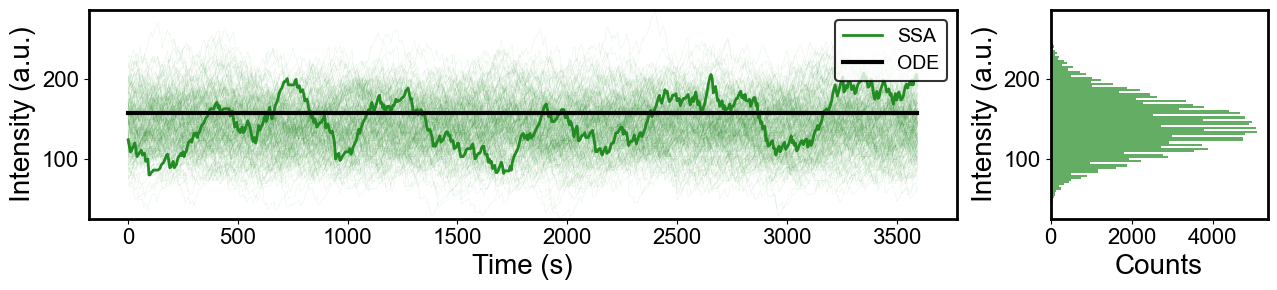

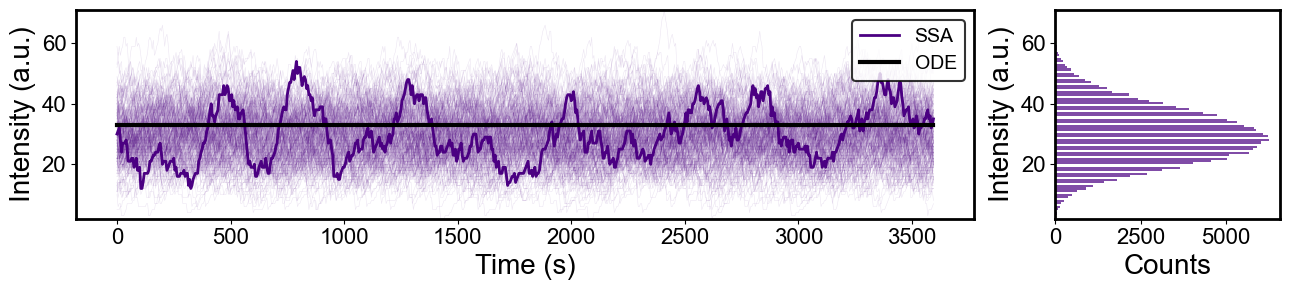

In [10]:
plot_trajectories(matrix_intensity_first_signal_RT, intensity_vector_first_signal_ode, time_array, number_repetitions,plot_color='forestgreen')
plot_trajectories(matrix_intensity_second_signal_RT, intensity_vector_second_signal_ode, time_array, number_repetitions,plot_color='indigo')

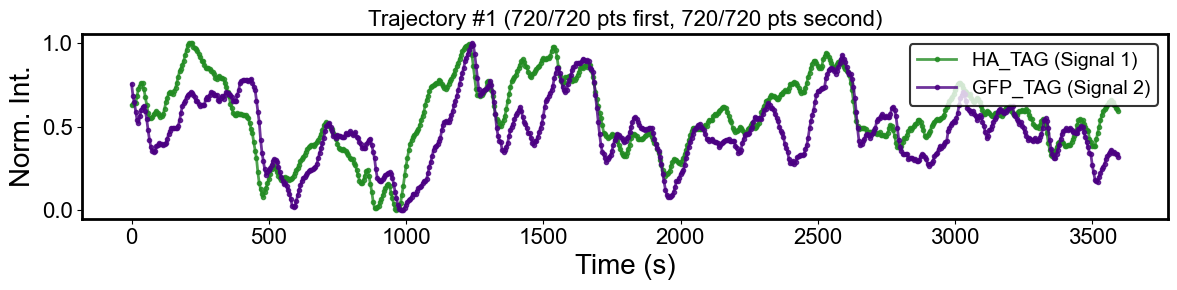

In [11]:
plot_dual_signal_trajectories(matrix_intensity_first_signal_RT, matrix_intensity_second_signal_RT, 
                              time_array, trajectory_index=1, 
                              colors=['forestgreen', 'indigo'], 
                              labels=['HA_TAG (Signal 1)', 'GFP_TAG (Signal 2)'], 
                              smooth_window=5,
                              normalize=True)

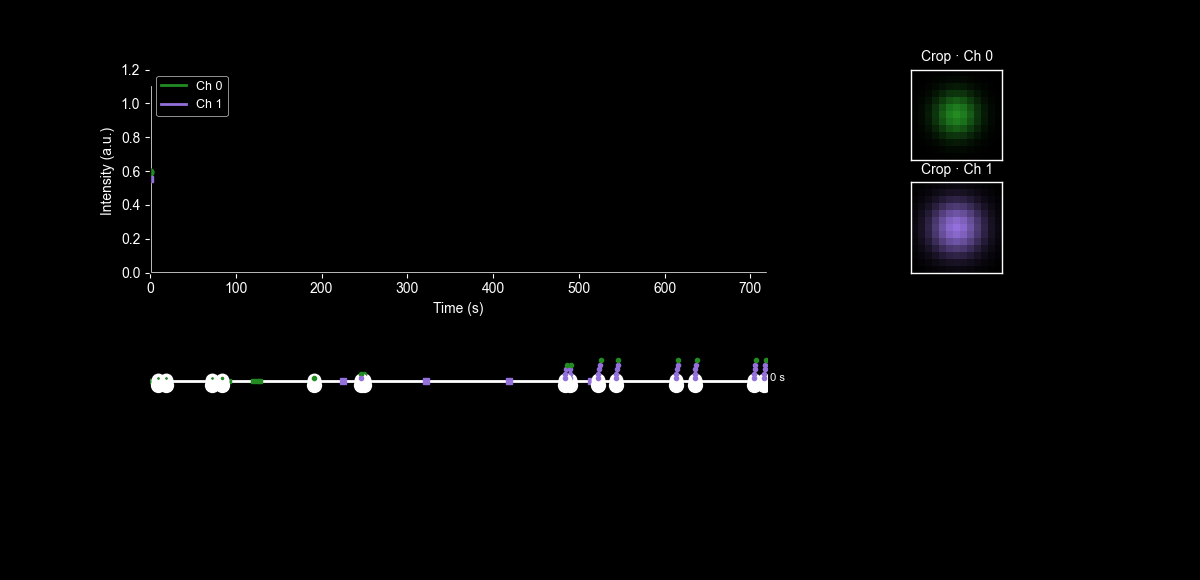

Exception ignored in: <function ResourceTracker.__del__ at 0x108f47560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [19]:
# plot the animation of the ribosome movement


str_ki = str(ki).replace('.','_')
str_k = str(global_elongation_rate).replace('.','_')
fileNameGif = 'simulation_'+plasmid_name+'_ke_'+str_k+'_ki_'+str_ki 
selected_index_trajectory = 0  # Change this index to visualize different trajectories
ribosome_trajectories = list_ribosome_trajectories[selected_index_trajectory]
intensity_vector_first_signal = matrix_intensity_first_signal_RT[selected_index_trajectory]
intensity_vector_second_signal = matrix_intensity_second_signal_RT[selected_index_trajectory]
tag_positions_first_probe_vector = data_sequence['probe_data']['tag_0']['positions']
tag_positions_second_probe_vector = data_sequence['probe_data']['tag_1']['positions']
#color = 'forestgreen'
#second_color = 'mediumpurple'

# second_color = 'lightgreen'
# #color = 'mediumpurple'
# color = 'magenta'

color = 'forestgreen'
second_color = 'mediumpurple'

plot_RibosomeMovement_and_Microscope(ribosome_trajectories, intensity_vector_first_signal, tag_positions_first_probe_vector, SecondIntensityVector=intensity_vector_second_signal, second_probePositions=tag_positions_second_probe_vector,FrameVelocity=10,fileNameGif=fileNameGif,color=color,second_color=second_color)

In [13]:

# calculating the mean occupancy across all frames
gene_length = data_sequence['gene_length']
ribosomal_density = np.round( (gene_length/global_elongation_rate) *ki , 1)
print(f'Ribosomal density: {ribosomal_density} ribosomes per gene length ({gene_length} codons)')
ribosomal_footprint = 10
ribosomal_density_coverage = np.round( (ribosomal_density * ribosomal_footprint) / gene_length, 2)
percentage_coverage = (ribosomal_density_coverage * 100)  # percentage coverage of the gene length by ribosomes
print(f'Ribosomal density coverage: {np.round(ribosomal_density_coverage,2)} ribosomes per gene length ({gene_length} codons, {percentage_coverage:.2f}% coverage)')
len(list_occupancy_output)
occupancy_array = np.array([np.mean(np.count_nonzero(occupancy, axis=0)) for occupancy in list_occupancy_output])
print(f'Ribosomal density with simulated data: { np.round( np.mean(occupancy_array), 2)} ribosomes per gene length ({gene_length} codons)')


Ribosomal density: 21.9 ribosomes per gene length (1826 codons)
Ribosomal density coverage: 0.12 ribosomes per gene length (1826 codons, 12.00% coverage)
Ribosomal density with simulated data: 16.26 ribosomes per gene length (1826 codons)


In [14]:

mean_correlation_ssa, std_correlation_ssa, lags_ssa, correlations_array, dwell_time = mi.Correlation(primary_data=matrix_intensity_first_signal_RT,   # HA first (reference)
                                                                                                    secondary_data=matrix_intensity_second_signal_RT, # GFP second (delayed)
                                                                                                    max_lag=None, 
                                                                                                    nan_handling='forward_fill',  #forward_fill, 'ignore'
                                                                                                    shift_data=True,
                                                                                                    return_full=True,
                                                                                                    time_interval_between_frames_in_seconds=step_size_in_sec,
                                                                                                    use_bootstrap=True,
                                                                                                    show_plot=False,
                                                                                                    start_lag=0,
                                                                                                    fit_type='linear',
                                                                                                    de_correlation_threshold=0.1,
                                                                                                    correct_baseline=True,
                                                                                                    use_linear_projection_for_lag_0=True,
                                                                                                    save_plots=False,
                                                                                                    use_global_mean= False,
                                                                                                    remove_outliers = True,
                                                                                                    MAD_THRESHOLD_FACTOR = 6,
                                                                                                    plot_individual_trajectories = False,
                                                                                                    x_axes_min_max_list_values=[-300,300],
                                                                                                    plot_title=None).run()

In [15]:
global_elongation_rate

5

In [16]:
# Expected values based on your parameters
tag_0_positions = data_sequence['probe_data']['tag_0']['positions']  # HA_TAG
tag_1_positions = data_sequence['probe_data']['tag_1']['positions']  # GFP_TAG
print("-" * 40)
print(f"Tag 0 positions (HA_TAG): {tag_0_positions}")
print(f"Tag 1 positions (GFP_TAG): {tag_1_positions}")
print("-" * 40)

avg_distance = np.mean(tag_1_positions) - np.mean(tag_0_positions)
expected_transit_time = avg_distance / global_elongation_rate
expected_lag_frames = expected_transit_time / step_size_in_sec
print("-" * 40)
print(f"Expected distance: {avg_distance:.1f} codons")
print(f"Expected transit time: {expected_transit_time:.1f} seconds") 
print("-" * 40)

# calculate this considering the last position of tag 0 and the first position of tag 1
avg_distance_edge = np.min(tag_1_positions) - np.max(tag_0_positions)
expected_transit_time_edge = avg_distance_edge / global_elongation_rate
expected_lag_frames_edge = expected_transit_time_edge / step_size_in_sec
print("-" * 40)
print(f"Expected distance (edge to edge): {avg_distance_edge:.1f} codons")
print(f"Expected transit time (edge to edge): {expected_transit_time_edge:.1f} seconds")
print("-" * 40)

----------------------------------------
Tag 0 positions (HA_TAG): [1, 11, 21, 198, 209, 222, 233, 306, 316, 326]
Tag 1 positions (GFP_TAG): [572, 817, 1062, 1307]
----------------------------------------
----------------------------------------
Expected distance: 755.2 codons
Expected transit time: 151.0 seconds
----------------------------------------
----------------------------------------
Expected distance (edge to edge): 246.0 codons
Expected transit time (edge to edge): 49.2 seconds
----------------------------------------


In [17]:
gene_length = data_sequence['gene_length']
tested_elongation_rates = [2, 4, 6, 8, 10]
for rate in tested_elongation_rates:
    total_transit_time = gene_length / rate
    print(f"Total transit time (full length) at {rate} codons/sec: {total_transit_time:.1f} seconds")

Total transit time (full length) at 2 codons/sec: 913.0 seconds
Total transit time (full length) at 4 codons/sec: 456.5 seconds
Total transit time (full length) at 6 codons/sec: 304.3 seconds
Total transit time (full length) at 8 codons/sec: 228.2 seconds
Total transit time (full length) at 10 codons/sec: 182.6 seconds


Centroid: 67.7 s
Asymmetry: 0.518


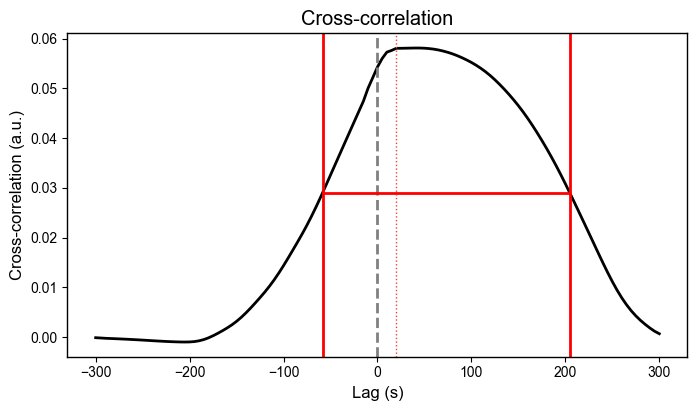

In [18]:
def analyze_crosscorr(
    corr,
    dt=5.0,
    lags_s=None,
    zero_index=None,
    window_s=600.0,
    slope_window_pts=3,
    halfmax_fraction=0.5,
    plot=False,
    ax=None,
):
    """
    Analyze a cross-correlation curve to extract delay/shape metrics.

    Parameters
    ----------
    corr : (N,) array
        Cross-correlation values vs. lag. Can contain NaNs.
    dt : float, default 5.0
        Sampling interval (seconds per frame), used if lags_s is not provided.
    lags_s : (N,) array or None
        Lag axis in seconds. If None, it's built assuming zero-lag at `zero_index`
        (or at the center if `zero_index` is None).
    zero_index : int or None
        Index corresponding to lag = 0 s (if lags_s is None). Defaults to N//2.
    window_s : float, default 600.0
        Time window (±window_s) used for area-asymmetry calculation.
    slope_window_pts : int, default 3
        Number of points on each side of 0-lag used for local slope fits.
    halfmax_fraction : float, default 0.5
        Fraction of peak for "dominant range" threshold (0.5 = FWHM).
    plot : bool, default False
        If True, plots the (interpolated) correlation and annotations.
    ax : matplotlib.axes.Axes or None
        Existing axis to plot into (only used if plot=True).

    Returns
    -------
    metrics : dict
        {
          'n_points', 'dt_seconds', 'peak_lag_seconds', 'peak_value',
          'centroid_lag_seconds', 'FWHM_seconds',
          'FWHM_left_crossing_seconds', 'FWHM_right_crossing_seconds',
          'slope_left_at_0_per_s', 'slope_right_at_0_per_s',
          'area_asymmetry_pm_window', 'dominant_left_seconds',
          'dominant_right_seconds'
        }
    corr_interp, lags_s : arrays
        Interpolated correlation and lag axis actually used.
    """
    corr = np.asarray(corr).astype(float).squeeze()
    if corr.ndim != 1:
        raise ValueError(f"corr must be 1D, got shape {corr.shape}")

    N = len(corr)

    # Build lag axis if not provided
    if lags_s is None:
        if zero_index is None:
            zero_index = N // 2
        lags_frames = np.arange(N) - int(zero_index)
        lags_s = lags_frames * float(dt)
    else:
        lags_s = np.asarray(lags_s).astype(float).squeeze()
        if lags_s.shape != corr.shape:
            raise ValueError("lags_s must have same shape as corr")

    # Interpolate NaNs linearly for stable metrics/plotting
    finite = np.isfinite(corr)
    corr_interp = corr.copy()
    if not np.all(finite):
        good = np.where(finite)[0]
        bad = np.where(~finite)[0]
        if good.size == 0:
            raise ValueError("corr contains no finite values")
        # Edge fill with nearest, interior with linear interp
        corr_interp[bad] = np.interp(bad, good, corr[good])

    # Peak
    # peak_idx = int(np.argmax(corr_interp))
    # peak_val = float(corr_interp[peak_idx])
    # peak_lag = float(lags_s[peak_idx])
    # Peak finding: closest to zero within 5% of global maximum
    global_max_val = float(np.max(corr_interp))
    tolerance = 0.005
    threshold = global_max_val * (1.0 - tolerance)

    # Find all peaks within tolerance
    candidate_mask = corr_interp >= threshold
    candidate_indices = np.where(candidate_mask)[0]

    if len(candidate_indices) > 1:
        # Multiple candidates: choose closest to zero lag
        zero_idx = int(np.argmin(np.abs(lags_s - 0.0)))
        distances = np.abs(candidate_indices - zero_idx)
        peak_idx = candidate_indices[np.argmin(distances)]
    else:
        # Single candidate or fallback to global max
        peak_idx = int(np.argmax(corr_interp))

    peak_val = float(corr_interp[peak_idx])
    peak_lag = float(lags_s[peak_idx])

    # Weighted centroid (shift corr to be nonnegative)
    y_shift = corr_interp - np.min(corr_interp)
    denom = y_shift.sum()
    centroid = float(np.sum(lags_s * y_shift) / denom) if denom > 0 else np.nan

    # Half-maximum crossings & FWHM (linear interpolation)
    def _halfmax_crossings(x, y, frac=0.5):
        p = int(np.argmax(y))
        pk = float(y[p])
        hm = frac * pk
        left_x = np.nan
        for i in range(p, 0, -1):
            y1, y2 = y[i-1], y[i]
            if (y1 - hm) * (y2 - hm) <= 0:
                x1, x2 = x[i-1], x[i]
                left_x = x1 if y2 == y1 else x1 + (hm - y1) * (x2 - x1) / (y2 - y1)
                break
        right_x = np.nan
        for i in range(p, len(y)-1):
            y1, y2 = y[i], y[i+1]
            if (y1 - hm) * (y2 - hm) <= 0:
                x1, x2 = x[i], x[i+1]
                right_x = x2 if y2 == y1 else x1 + (hm - y1) * (x2 - x1) / (y2 - y1)
                break
        width = float(right_x - left_x) if np.isfinite(left_x) and np.isfinite(right_x) else np.nan
        return width, left_x, right_x

    FWHM, left_hm, right_hm = _halfmax_crossings(lags_s, corr_interp, frac=0.5)

    # Dominant range at specified fraction (contiguous region around peak above threshold)
    def _dominant_range(x, y, frac=0.5):
        p = int(np.argmax(y))
        thresh = frac * float(y[p])
        L = p
        while L-1 >= 0 and y[L-1] >= thresh:
            L -= 1
        R = p
        while R+1 < len(y) and y[R+1] >= thresh:
            R += 1
        return float(x[L]), float(x[R])

    dom_left, dom_right = _dominant_range(lags_s, corr_interp, frac=halfmax_fraction)

    # Local slopes at 0 (least-squares line fits on small neighborhoods)
    idx0 = int(np.argmin(np.abs(lags_s - 0.0)))
    L_slice = slice(max(0, idx0 - slope_window_pts), idx0 + 1)
    R_slice = slice(idx0, min(N, idx0 + slope_window_pts + 1))

    def _fit_slope(x, y):
        if len(x) < 2:
            return np.nan
        A = np.vstack([x, np.ones_like(x)]).T
        m, _ = np.linalg.lstsq(A, y, rcond=None)[0]
        return float(m)

    slope_left = _fit_slope(lags_s[L_slice], corr_interp[L_slice])
    slope_right = _fit_slope(lags_s[R_slice], corr_interp[R_slice])

    # Area asymmetry in ±window_s (only positive parts to avoid negative lobes bias)
    step = float(np.median(np.diff(lags_s)))
    wmask = np.abs(lags_s) <= float(window_s)
    xw = lags_s[wmask]
    yw = corr_interp[wmask]
    pos_area = float(np.sum(np.clip(yw[xw > 0], 0, None)) * step) if np.any(xw > 0) else 0.0
    neg_area = float(np.sum(np.clip(yw[xw < 0], 0, None)) * step) if np.any(xw < 0) else 0.0
    asym = (pos_area - neg_area) / (pos_area + neg_area + 1e-12)

    metrics = {
        "n_points": N,
        "dt_seconds": float(dt),
        "peak_lag_seconds": peak_lag,
        "peak_value": peak_val,
        "centroid_lag_seconds": centroid,
        "FWHM_seconds": FWHM,
        "FWHM_left_crossing_seconds": left_hm,
        "FWHM_right_crossing_seconds": right_hm,
        "slope_left_at_0_per_s": slope_left,
        "slope_right_at_0_per_s": slope_right,
        "area_asymmetry_pm_window": asym,
        "dominant_left_seconds": dom_left,
        "dominant_right_seconds": dom_right,
    }

    if plot:
        import matplotlib.pyplot as plt
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 4.2))
        ax.plot(lags_s, corr_interp, lw=2, color="k")
        ax.axvline(0, ls="--", lw=2, color="gray")
        ax.axvline(peak_lag, ls=":", lw=1)
        if np.isfinite(FWHM):
            ax.axvline(left_hm, ls="-", lw=2, color="r")
            ax.axvline(right_hm, ls="-", lw=2, color="r")
        # plot horizontal line at half max
            ax.hlines(halfmax_fraction * peak_val, left_hm, right_hm, color="r", lw=2)
        ax.set_title("Cross-correlation")
        ax.set_xlabel("Lag (s)")
        ax.set_ylabel("Cross-correlation (a.u.)")
        ax.grid(True, alpha=0.2)
        if ax is None:
            plt.tight_layout()
            plt.show()

    return metrics, corr_interp, lags_s

max_lag_selected = 300
original_mean_correlation_ssa = mean_correlation_ssa.copy()
original_lags_ssa = lags_ssa.copy()
lag_mask = (original_lags_ssa >= -max_lag_selected) & (original_lags_ssa <= max_lag_selected)
mean_correlation_ssa_masked = original_mean_correlation_ssa[lag_mask]
# smooth the mean correlation every 3 points to reduce noise
mean_correlation_ssa_masked = np.convolve(mean_correlation_ssa_masked, np.ones(5)/5, mode='same')

lags_ssa_masked = original_lags_ssa[lag_mask]
metrics, corr_interp, lags_s = analyze_crosscorr(mean_correlation_ssa_masked, dt=step_size_in_sec, plot=True)

# print("-" * 40)
# print(f"Time delay: {metrics['peak_lag_seconds']:.1f} s")
# print("-" * 40)

#print(f"Peak value: {metrics['peak_value']:.4f}")
#print(f"FWHM: {metrics['FWHM_seconds']:.1f} s")
print(f"Centroid: {metrics['centroid_lag_seconds']:.1f} s")
print(f"Asymmetry: {metrics['area_asymmetry_pm_window']:.3f}")

# Negative asymmetry (-): GFP signal precedes HA signal → unexpected (would indicate reverse flow)

Decorrelation threshold value: 0.005591130266472182


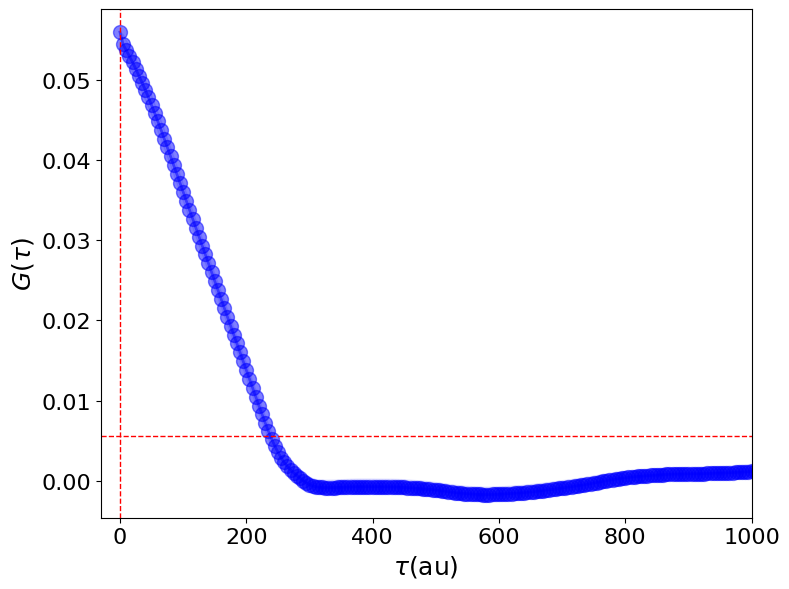

Exception ignored in: <function ResourceTracker.__del__ at 0x105f47560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105947560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function Resour

In [ ]:
mean_correlation_ssa, std_correlation_ssa, lags_ssa, correlations_array, dwell_time = mi.Correlation(primary_data=matrix_intensity_first_signal_RT,   # HA first (reference)
                                                                                                    secondary_data=None, # GFP second (delayed)
                                                                                                    max_lag=None, 
                                                                                                    nan_handling='forward_fill',  #forward_fill, 'ignore'
                                                                                                    shift_data=True,
                                                                                                    return_full=False,
                                                                                                    time_interval_between_frames_in_seconds=step_size_in_sec,
                                                                                                    use_bootstrap=True,
                                                                                                    show_plot=True,
                                                                                                    start_lag=0,
                                                                                                    fit_type='linear',
                                                                                                    de_correlation_threshold=0.1,
                                                                                                    correct_baseline=True,
                                                                                                    use_linear_projection_for_lag_0=True,
                                                                                                    save_plots=False,
                                                                                                    use_global_mean= False,
                                                                                                    remove_outliers = True,
                                                                                                    MAD_THRESHOLD_FACTOR = 6,
                                                                                                    plot_individual_trajectories = False,
                                                                                                    x_axes_min_max_list_values=[-30,1000],
                                                                                                    plot_title=None).run()